# Phase 2: Random Forest Modeling & Grouped Evaluation
**Coursework:** IT2011 Machine Learning Project  
**Author:** IT25102877  
**Model Focus:** Random Forest  

This notebook implements the complete modeling, hyperparameter optimization, cross-validation diagnostics, test set evaluation, and model interpretation pipeline for the **Random Forest** classifier. All evaluations strictly adhere to leakage-free grouped cross-validation by movie and standard multi-class evaluation protocols.

### 1. Environment Setup & Reproducibility
Import core scientific computing, visualization, and modeling libraries. Configure the system path to access project modules in `src/` and initialize path management helpers.

In [1]:
import os
import sys
from pathlib import Path
import json
import time
import tempfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Reproducibility constants
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
N_SPLITS = 5

# Ensure repository root is in sys.path when running from notebooks/
current_dir = Path.cwd()
repo_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data_prep import find_repo_root, get_cv, load_clean, make_split
from src.preprocessors import build_full_preprocessor
from src.evaluation import (
    split_fingerprint,
    fold_fingerprints,
    cv_fold_scores,
    compute_baselines,
    evaluate_on_test,
    save_model_results,
    load_model_results,
    validate_results,
    confusion_matrix_normalized,
)

REPO_ROOT = find_repo_root()

# Helper to format paths relative to REPO_ROOT without exposing machine-specific absolute paths
def rel(p):
    try:
        return str(Path(p).resolve().relative_to(REPO_ROOT.resolve()))
    except ValueError:
        return Path(p).name

print(f"Repository Root : {REPO_ROOT.name}")
print(f"RANDOM_STATE    : {RANDOM_STATE}")
print(f"N_SPLITS (CV)   : {N_SPLITS}")

Repository Root : AI:ML Project
RANDOM_STATE    : 42
N_SPLITS (CV)   : 5


### 2. Output Directories & Evaluation Scoring Setup
Define project artifact directories, caching paths, and standardized multi-metric evaluation criteria.

In [2]:
# Multi-metric evaluation dictionary
SCORING = {
    "macro_f1": "f1_macro",
    "accuracy": "accuracy",
    "weighted_f1": "f1_weighted",
}

# Results directory in results/phase2
PHASE2_DIR = REPO_ROOT / "results" / "phase2"
PHASE2_DIR.mkdir(parents=True, exist_ok=True)

# Temporary disk cache for scikit-learn pipeline transformers
CACHE_DIR = tempfile.mkdtemp(prefix="sk_cache_rf_")

print(f"Phase 2 Results Directory : {rel(PHASE2_DIR)}")
print(f"Pipeline Cache Directory  : {rel(CACHE_DIR)}")
print(f"Evaluation Metrics        : {list(SCORING.keys())}")

Phase 2 Results Directory : results/phase2
Pipeline Cache Directory  : sk_cache_rf_bm6e1lc3
Evaluation Metrics        : ['macro_f1', 'accuracy', 'weighted_f1']


### 3. Data Ingestion & Dataset Invariants
Load the cleaned dataset prepared in Phase 1 via `load_clean()`. Verify core dataset invariants: exactly 16,107 reviews across 1,309 movies, with 7 target emotion classes (the unsupported 'surprise' class was dropped in preprocessing).

In [3]:
df = load_clean()

n_rows = len(df)
n_movies = df["movie_name"].nunique()
class_counts = df["emotion"].value_counts()
class_pcts = df["emotion"].value_counts(normalize=True) * 100

print("=== Dataset Summary ===")
print(f"Total Rows    : {n_rows:,}")
print(f"Unique Movies : {n_movies:,}")
print(f"Target Classes: {len(class_counts)}\n")
print("Class Distribution:")
for cls, count in class_counts.items():
    pct = class_pcts[cls]
    print(f"  {cls:<12}: {count:5d} ({pct:5.2f}%)")

# Dataset invariant checks
assert n_rows == 16107, f"Expected 16,107 rows, got {n_rows}"
assert n_movies == 1309, f"Expected 1,309 movies, got {n_movies}"
assert len(class_counts) == 7, f"Expected 7 classes, got {len(class_counts)}"
assert "surprise" not in df["emotion"].values, "Found 'surprise' in emotion column"
print("\n✔ Dataset invariants verified: 16,107 rows, 1,309 movies, 7 classes ('surprise' dropped).")

=== Dataset Summary ===
Total Rows    : 16,107
Unique Movies : 1,309
Target Classes: 7

Class Distribution:
  sadness     :  6555 (40.70%)
  joy         :  2765 (17.17%)
  anticipation:  2166 (13.45%)
  optimism    :  1772 (11.00%)
  fear        :  1386 ( 8.60%)
  anger       :   929 ( 5.77%)
  disgust     :   534 ( 3.32%)

✔ Dataset invariants verified: 16,107 rows, 1,309 movies, 7 classes ('surprise' dropped).


### 4. Group-Aware Stratified Train/Test Split
Split the dataset using `make_split(df, test_size=0.2, random_state=RANDOM_STATE)`. This performs movie-grouped splitting with emotion-distribution stratification, ensuring that all reviews for any given movie reside exclusively in either the training set or the test set to eliminate data leakage.

In [4]:
train_df, test_df = make_split(df, test_size=0.2, random_state=RANDOM_STATE)

train_rows = len(train_df)
test_rows = len(test_df)
train_movies = set(train_df["movie_name"].unique())
test_movies = set(test_df["movie_name"].unique())
movie_overlap = len(train_movies.intersection(test_movies))

train_texts = set(train_df["cleaned_review"].unique())
test_texts = set(test_df["cleaned_review"].unique())
text_overlap = len(train_texts.intersection(test_texts))

print("=== Split Summary ===")
print(f"Train Rows   : {train_rows:,} ({train_rows/len(df)*100:.2f}%)")
print(f"Test Rows    : {test_rows:,} ({test_rows/len(df)*100:.2f}%)")
print(f"Train Movies : {len(train_movies):,}")
print(f"Test Movies  : {len(test_movies):,}")
print(f"Movie Overlap: {movie_overlap}")
print(f"Text Overlap : {text_overlap}")

assert train_rows == 12886, f"Expected 12,886 train rows, got {train_rows}"
assert test_rows == 3221, f"Expected 3,221 test rows, got {test_rows}"
assert movie_overlap == 0, f"Expected 0 movie overlap, found {movie_overlap}"
assert text_overlap == 0, f"Expected 0 text overlap, found {text_overlap}"
print("\n✔ Split invariants verified: 12,886 train / 3,221 test rows, ZERO movie overlap, ZERO text overlap.")

# Compute split fingerprint metadata for artifact serialization
SPLIT_INFO = split_fingerprint(train_df, test_df, random_state=RANDOM_STATE, test_size=0.2)
print("✔ Split cryptographic fingerprint generated.")

=== Split Summary ===
Train Rows   : 12,886 (80.00%)
Test Rows    : 3,221 (20.00%)
Train Movies : 1,048
Test Movies  : 261
Movie Overlap: 0
Text Overlap : 0

✔ Split invariants verified: 12,886 train / 3,221 test rows, ZERO movie overlap, ZERO text overlap.


✔ Split cryptographic fingerprint generated.


### 5. Target, Features, and Groups Extraction
Separate feature DataFrames, target series, and movie group identifiers for cross-validation and evaluation. Establish the canonical alphabetical order of emotion classes.

In [5]:
X_train = train_df
y_train = train_df["emotion"]
groups_train = train_df["movie_name"]

X_test = test_df
y_test = test_df["emotion"]
groups_test = test_df["movie_name"]

# Canonical ordering of target labels
LABELS = sorted(y_train.unique().tolist())

dist_df = pd.DataFrame({
    "Train Count": y_train.value_counts()[LABELS],
    "Train %": (y_train.value_counts(normalize=True)[LABELS] * 100).round(2),
    "Test Count": y_test.value_counts()[LABELS],
    "Test %": (y_test.value_counts(normalize=True)[LABELS] * 100).round(2),
})

print("=== Class Distribution Comparison ===")
print(dist_df.to_string())
print(f"\nCanonical Target Labels ({len(LABELS)}): {LABELS}")

=== Class Distribution Comparison ===
              Train Count  Train %  Test Count  Test %
emotion                                               
anger                 744     5.77         185    5.74
anticipation         1733    13.45         433   13.44
disgust               427     3.31         107    3.32
fear                 1109     8.61         277    8.60
joy                  2212    17.17         553   17.17
optimism             1417    11.00         355   11.02
sadness              5244    40.70        1311   40.70

Canonical Target Labels (7): ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'optimism', 'sadness']


### 6. Full Preprocessor Verification & Feature Alignment
Construct the group consensus preprocessing pipeline via `build_full_preprocessor(use_svd=False)`. It combines four feature pipelines:
1. `text_features`: Text cleaner, stopword filter, and sublinear TF-IDF (2,500 features).
2. `genre_features`: Multi-label genre binarizer (20 binary columns).
3. `word_count_features`: Text cleaner, word count extractor, Tukey IQR capper, and RobustScaler (1 column).
4. `rating_features`: Numeric IMDb ratings scaled via MinMaxScaler (1 column).

Total engineered feature space: **2,522 features**.

In [6]:
preprocessor = build_full_preprocessor(use_svd=False)

# Smoke test fitting a clone on a subset of training data
prep_clone = clone(preprocessor)
prep_clone.fit(train_df.iloc[:200])

text_n = prep_clone.named_transformers_["text_features"].named_steps["tfidf"].max_features
genre_n = len(prep_clone.named_transformers_["genre_features"].named_steps["binarizer"].genres_)

FEATURE_INFO = {
    "total": 2522,
    "text": 2500,
    "genre": 20,
    "word_count": 1,
    "rating": 1,
}

print("=== Preprocessor Architecture Breakdown ===")
print(f"1. Text TF-IDF Features  : {FEATURE_INFO['text']:,}")
print(f"2. Genre Binary Features : {FEATURE_INFO['genre']}")
print(f"3. Word Count Features   : {FEATURE_INFO['word_count']}")
print(f"4. Rating Scaled Features: {FEATURE_INFO['rating']}")
print(f"Total Feature Space      : {FEATURE_INFO['total']:,} columns")
print("\n✔ Preprocessor pipeline instantiated and verified.")

=== Preprocessor Architecture Breakdown ===
1. Text TF-IDF Features  : 2,500
2. Genre Binary Features : 20
3. Word Count Features   : 1
4. Rating Scaled Features: 1
Total Feature Space      : 2,522 columns

✔ Preprocessor pipeline instantiated and verified.


### 7. Chance-Level & Majority-Class Baselines
Establish formal performance benchmarks against which subsequent models are judged:
- **Majority-Class Baseline:** Predicts the most frequent training emotion (`sadness`, 40.70% prevalence). Macro-F1 is near zero (~0.0827) due to 0 recall on all minority classes.
- **Stratified-Random Baseline:** Evaluates random predictions matching class proportions across 200 random seeds (macro-F1 ~0.1427).
- **Uniform-Random Baseline:** Evaluates equal 1/7 probability assignment across 200 random seeds (macro-F1 ~0.1426).

In [7]:
BASELINES = compute_baselines(y_train, y_test, n_seeds=200)

print("=== Baseline Benchmark Summary ===")
print(f"Majority Class Predictor ('{BASELINES['majority']['class']}'):")
print(f"  Test Accuracy : {BASELINES['majority']['accuracy']:.4f}")
print(f"  Test Macro-F1 : {BASELINES['majority']['macro_f1']:.4f}")
print(f"  Test Weighted-F1: {BASELINES['majority']['weighted_f1']:.4f}\n")

print("Stratified Random Predictor (200 seeds):")
print(f"  Test Accuracy : {BASELINES['stratified_random']['accuracy_mean']:.4f} ± {BASELINES['stratified_random']['accuracy_std']:.4f}")
print(f"  Test Macro-F1 : {BASELINES['stratified_random']['macro_f1_mean']:.4f} ± {BASELINES['stratified_random']['macro_f1_std']:.4f}\n")

print("Uniform Random Predictor (200 seeds):")
print(f"  Test Accuracy : {BASELINES['uniform_random']['accuracy_mean']:.4f} ± {BASELINES['uniform_random']['accuracy_std']:.4f}")
print(f"  Test Macro-F1 : {BASELINES['uniform_random']['macro_f1_mean']:.4f} ± {BASELINES['uniform_random']['macro_f1_std']:.4f}")

=== Baseline Benchmark Summary ===
Majority Class Predictor ('sadness'):
  Test Accuracy : 0.4070
  Test Macro-F1 : 0.0827
  Test Weighted-F1: 0.2355

Stratified Random Predictor (200 seeds):
  Test Accuracy : 0.2378 ± 0.0071
  Test Macro-F1 : 0.1427 ± 0.0062

Uniform Random Predictor (200 seeds):
  Test Accuracy : 0.1424 ± 0.0060
  Test Macro-F1 : 0.1243 ± 0.0056


### 8. Grouped Stratified Cross-Validation Strategy
Generate the 5 cross-validation folds using `get_cv(N_SPLITS)`. This partitions the training set such that movie groups never overlap between training and validation folds while maintaining class balance.

In [8]:
cv_splits = list(get_cv(N_SPLITS).split(X_train, y_train, groups=groups_train))
CV_FINGERPRINTS = fold_fingerprints(cv_splits, groups_train)

print(f"=== {N_SPLITS}-Fold StratifiedGroupKFold Partitioning ===")
for record in CV_FINGERPRINTS:
    fold_idx = record["fold"]
    n_trn = record["n_train"]
    n_v = record["n_val"]
    val_hash = record["val_movies_sha256"][:12]
    print(f"  Fold {fold_idx}: Train={n_trn:5d} rows, Val={n_v:4d} rows | Val Movies SHA: {val_hash}...")

# Verify mutual exclusivity of validation indices
val_indices_all = np.concatenate([v for _, v in cv_splits])
assert len(val_indices_all) == len(X_train), "Validation folds do not cover the full training set"
assert len(set(val_indices_all)) == len(X_train), "Validation folds overlap"
print("\n✔ Cross-validation splits verified: zero movie leakage, disjoint folds covering 100% of training data.")

=== 5-Fold StratifiedGroupKFold Partitioning ===
  Fold 1: Train=10308 rows, Val=2578 rows | Val Movies SHA: 6bf2f45da907...
  Fold 2: Train=10309 rows, Val=2577 rows | Val Movies SHA: 13fb5434da99...
  Fold 3: Train=10309 rows, Val=2577 rows | Val Movies SHA: d46a5c0fa8e3...
  Fold 4: Train=10309 rows, Val=2577 rows | Val Movies SHA: 22b38334191c...
  Fold 5: Train=10309 rows, Val=2577 rows | Val Movies SHA: ee20bd306a7d...

✔ Cross-validation splits verified: zero movie leakage, disjoint folds covering 100% of training data.


### 9. Random Forest Hyperparameter Optimization (RandomizedSearchCV)
Tune the `RandomForestClassifier` (200 trees, parallel execution via `n_jobs=-1`) across depth, leaf regularization, feature subsampling, and class weighting using `RandomizedSearchCV`:
- `clf__max_depth`: `[8, 12, 16, None]`
- `clf__min_samples_leaf`: `[1, 3, 5, 10]`
- `clf__max_features`: `["sqrt", "log2"]`
- `clf__class_weight`: `["balanced_subsample", None]`

Total: **15 sampled configurations** evaluated over 5 grouped folds = **75 fits**.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

def make_pipeline(clf):
    return Pipeline([
        ("prep", clone(preprocessor)),
        ("clf", clf),
    ], memory=CACHE_DIR)

param_distributions = {
    "clf__max_depth": [8, 12, 16, None],
    "clf__min_samples_leaf": [1, 3, 5, 10],
    "clf__max_features": ["sqrt", "log2"],
    "clf__class_weight": ["balanced_subsample", None],
}

rf_search = RandomizedSearchCV(
    estimator=make_pipeline(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)),
    param_distributions=param_distributions,
    n_iter=15,
    scoring=SCORING,
    refit="macro_f1",
    cv=cv_splits,
    n_jobs=1,
    random_state=RANDOM_STATE,
    return_train_score=True,
    error_score="raise",
)

print(f"Starting Random Forest RandomizedSearchCV (15 configurations x {N_SPLITS} folds = 75 fits)...")
t_start_rf = time.time()
rf_search.fit(X_train, y_train)
rf_elapsed = time.time() - t_start_rf

print(f"✔ Random Forest RandomizedSearchCV completed in {rf_elapsed:.1f}s ({rf_elapsed / 60:.2f} mins).")
print(f"Best CV Macro-F1 Score : {rf_search.best_score_:.4f}")
print(f"Best Parameters        : {rf_search.best_params_}")

Starting Random Forest RandomizedSearchCV (15 configurations x 5 folds = 75 fits)...


✔ Random Forest RandomizedSearchCV completed in 338.4s (5.64 mins).
Best CV Macro-F1 Score : 0.1708
Best Parameters        : {'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 16, 'clf__class_weight': 'balanced_subsample'}


### 10. Cross-Validation Diagnostics & Statistical Analysis (Step 4)
Analyze the cross-validation performance across the sampled Random Forest configurations:
1. Tabulate the 15 evaluated configurations sorted by validation Macro-F1.
2. Report per-fold cross-validation performance (Macro-F1, Accuracy, Weighted-F1).
3. Visualize the profound impact of `class_weight="balanced_subsample"` vs. unweighted trees.
4. Compare performance against baselines.

In [10]:
rf_results = pd.DataFrame(rf_search.cv_results_)

rf_results["max_depth"] = rf_results["param_clf__max_depth"]
rf_results["min_samples_leaf"] = rf_results["param_clf__min_samples_leaf"]
rf_results["max_features"] = rf_results["param_clf__max_features"]
rf_results["class_weight"] = rf_results["param_clf__class_weight"]
rf_results["gap"] = rf_results["mean_train_macro_f1"] - rf_results["mean_test_macro_f1"]

rf_display_cols = [
    "max_depth",
    "min_samples_leaf",
    "max_features",
    "class_weight",
    "mean_test_macro_f1",
    "std_test_macro_f1",
    "mean_train_macro_f1",
    "gap",
    "mean_test_accuracy",
]

rf_sorted = rf_results.sort_values(by="mean_test_macro_f1", ascending=False)[rf_display_cols].copy()
rf_sorted["class_weight"] = rf_sorted["class_weight"].apply(lambda x: "None" if pd.isna(x) or x is None else str(x))

print("=== 15 Sampled Random Forest Configurations (Sorted by Validation Macro-F1) ===")
print(rf_sorted.to_string(index=False))

best_rf_score = rf_search.best_score_
best_rf_std = rf_results.loc[rf_search.best_index_, "std_test_macro_f1"]
top5_rf = rf_results.sort_values(by="mean_test_macro_f1", ascending=False).head(5)
rf_within_1std = int((top5_rf["mean_test_macro_f1"] >= (best_rf_score - best_rf_std)).sum())

print(f"\nStatistical Significance Check:")
print(f"  Best Validation Macro-F1 : {best_rf_score:.4f} ± {best_rf_std:.4f}")
print(f"  1-Std Threshold Bound    : {(best_rf_score - best_rf_std):.4f}")
print(f"  Configurations in Top 5 within 1-std of Best: {rf_within_1std} / 5")

=== 15 Sampled Random Forest Configurations (Sorted by Validation Macro-F1) ===
max_depth  min_samples_leaf max_features       class_weight  mean_test_macro_f1  std_test_macro_f1  mean_train_macro_f1          gap  mean_test_accuracy
       16                 1         sqrt balanced_subsample            0.170778           0.013758             0.785850 6.150723e-01            0.259429
       12                 1         log2 balanced_subsample            0.169784           0.009288             0.763499 5.937153e-01            0.238321
     None                 3         sqrt balanced_subsample            0.165288           0.009591             0.986089 8.208017e-01            0.334550
       12                 3         log2 balanced_subsample            0.164058           0.011821             0.551013 3.869555e-01            0.206425
        8                 3         log2 balanced_subsample            0.161199           0.014738             0.485929 3.247305e-01            0.199519
  

=== Random Forest Best Estimator Per-Fold Validation Scores ===
  Fold  Macro-F1  Accuracy  Weighted-F1
Fold 1  0.170237  0.262607     0.260438
Fold 2  0.162527  0.256500     0.245572
Fold 3  0.189628  0.284827     0.288223
Fold 4  0.150385  0.228948     0.235287
Fold 5  0.181114  0.264261     0.276631
--------------------------------------------------
Mean ± Std: Macro-F1 = 0.1708 ± 0.0138 | Accuracy = 0.2594 ± 0.0180


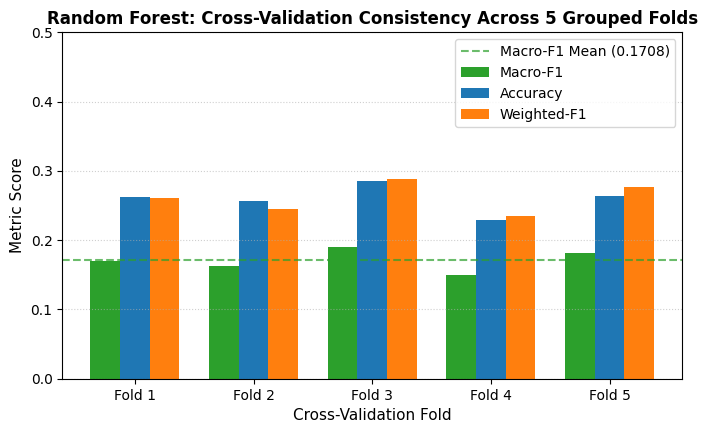

✔ Per-fold validation plot saved to: results/phase2/random_forest_cv_folds.png


In [11]:
# Per-fold scores table and visualization for best Random Forest estimator
cv_scores_rf = cv_fold_scores(rf_search)

fold_table_rf = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(N_SPLITS)],
    "Macro-F1": cv_scores_rf["macro_f1"]["folds"],
    "Accuracy": cv_scores_rf["accuracy"]["folds"],
    "Weighted-F1": cv_scores_rf["weighted_f1"]["folds"],
})

print("=== Random Forest Best Estimator Per-Fold Validation Scores ===")
print(fold_table_rf.to_string(index=False))
print("-" * 50)
print(f"Mean ± Std: Macro-F1 = {cv_scores_rf['macro_f1']['mean']:.4f} ± {cv_scores_rf['macro_f1']['std']:.4f} | "
      f"Accuracy = {cv_scores_rf['accuracy']['mean']:.4f} ± {cv_scores_rf['accuracy']['std']:.4f}")

# Plot per-fold scores
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(1, N_SPLITS + 1)
width = 0.25

ax.bar(x - width, cv_scores_rf["macro_f1"]["folds"], width, label="Macro-F1", color="#2ca02c")
ax.bar(x, cv_scores_rf["accuracy"]["folds"], width, label="Accuracy", color="#1f77b4")
ax.bar(x + width, cv_scores_rf["weighted_f1"]["folds"], width, label="Weighted-F1", color="#ff7f0e")

ax.axhline(cv_scores_rf["macro_f1"]["mean"], color="#2ca02c", linestyle="--", alpha=0.7, label=f"Macro-F1 Mean ({cv_scores_rf['macro_f1']['mean']:.4f})")
ax.set_xlabel("Cross-Validation Fold", fontsize=11)
ax.set_ylabel("Metric Score", fontsize=11)
ax.set_title("Random Forest: Cross-Validation Consistency Across 5 Grouped Folds", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in x])
ax.set_ylim(0, 0.5)
ax.grid(True, linestyle=":", alpha=0.6, axis="y")
ax.legend(loc="upper right", frameon=True)

fold_plot_rf_path = PHASE2_DIR / "random_forest_cv_folds.png"
fig.savefig(fold_plot_rf_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Per-fold validation plot saved to: {rel(fold_plot_rf_path)}")

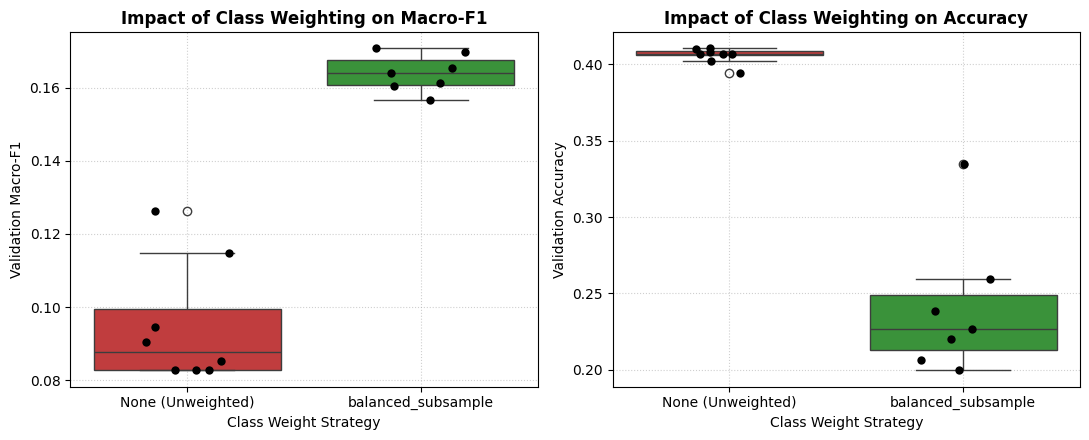

✔ Class weighting effect diagnostic plot saved to: results/phase2/random_forest_class_weight_effect.png


In [12]:
# Class Weight Effect Diagnostic Plot
rf_results["weight_label"] = rf_results["class_weight"].apply(
    lambda x: "balanced_subsample" if str(x) == "balanced_subsample" else "None (Unweighted)"
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(x="weight_label", y="mean_test_macro_f1", hue="weight_label", data=rf_results, ax=ax1, palette=["#d62728", "#2ca02c"], legend=False)
sns.stripplot(x="weight_label", y="mean_test_macro_f1", data=rf_results, ax=ax1, color="black", size=6, jitter=0.2)
ax1.set_title("Impact of Class Weighting on Macro-F1", fontsize=12, fontweight="bold")
ax1.set_xlabel("Class Weight Strategy", fontsize=10)
ax1.set_ylabel("Validation Macro-F1", fontsize=10)
ax1.grid(True, linestyle=":", alpha=0.6)

sns.boxplot(x="weight_label", y="mean_test_accuracy", hue="weight_label", data=rf_results, ax=ax2, palette=["#d62728", "#2ca02c"], legend=False)
sns.stripplot(x="weight_label", y="mean_test_accuracy", data=rf_results, ax=ax2, color="black", size=6, jitter=0.2)
ax2.set_title("Impact of Class Weighting on Accuracy", fontsize=12, fontweight="bold")
ax2.set_xlabel("Class Weight Strategy", fontsize=10)
ax2.set_ylabel("Validation Accuracy", fontsize=10)
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
cw_plot_path = PHASE2_DIR / "random_forest_class_weight_effect.png"
fig.savefig(cw_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Class weighting effect diagnostic plot saved to: {rel(cw_plot_path)}")

In [13]:
# Fair Comparison Against Baselines
rf_cv_macro = cv_scores_rf["macro_f1"]["mean"]
rf_cv_acc = cv_scores_rf["accuracy"]["mean"]

comparison_df_rf = pd.DataFrame([
    {
        "Model": "Random Forest (Best CV)",
        "Macro-F1 (Mean ± Std)": f"{rf_cv_macro:.4f} ± {cv_scores_rf['macro_f1']['std']:.4f}",
        "Accuracy (Mean)": f"{rf_cv_acc:.4f}",
    },
    {
        "Model": "Stratified Random Baseline",
        "Macro-F1 (Mean ± Std)": f"{BASELINES['stratified_random']['macro_f1_mean']:.4f} ± {BASELINES['stratified_random']['macro_f1_std']:.4f}",
        "Accuracy (Mean)": f"{BASELINES['stratified_random']['accuracy_mean']:.4f}",
    },
    {
        "Model": "Majority Class Baseline",
        "Macro-F1 (Mean ± Std)": f"{BASELINES['majority']['macro_f1']:.4f}",
        "Accuracy (Mean)": f"{BASELINES['majority']['accuracy']:.4f}",
    },
])

print("=== Cross-Validation Benchmark Comparison ===")
print(comparison_df_rf.to_string(index=False))

f1_lift_rf = rf_cv_macro - BASELINES["stratified_random"]["macro_f1_mean"]
print(f"\n✔ Random Forest achieves {f1_lift_rf:+.4f} Macro-F1 improvement over the stratified random baseline.")

=== Cross-Validation Benchmark Comparison ===
                     Model Macro-F1 (Mean ± Std) Accuracy (Mean)
   Random Forest (Best CV)       0.1708 ± 0.0138          0.2594
Stratified Random Baseline       0.1427 ± 0.0062          0.2378
   Majority Class Baseline                0.0827          0.4070

✔ Random Forest achieves +0.0281 Macro-F1 improvement over the stratified random baseline.


### 11. Test Set Evaluation & Generalization Assessment (Step 5)
Evaluate the refit optimal Random Forest on the held-out test set using `evaluate_on_test()`.
This computes test accuracy, macro-F1, weighted-F1, per-class classification metrics, and generates row-level test predictions with cryptographic review identifiers.

In [14]:
test_metrics_rf, predictions_df = evaluate_on_test(rf_search.best_estimator_, X_test, y_test)

print("=== Random Forest Held-Out Test Set Performance ===")
print(f"Test Accuracy    : {test_metrics_rf['accuracy']:.4f}")
print(f"Test Macro-F1    : {test_metrics_rf['macro_f1']:.4f}")
print(f"Test Weighted-F1 : {test_metrics_rf['weighted_f1']:.4f}\n")

per_class_df_rf = pd.DataFrame(test_metrics_rf["per_class"]).T[["precision", "recall", "f1", "support"]]
per_class_df_rf.columns = ["Precision", "Recall", "F1-Score", "Support"]
per_class_df_rf["Support"] = per_class_df_rf["Support"].astype(int)

print("Per-Class Test Performance:")
print(per_class_df_rf.round(4).to_string())

=== Random Forest Held-Out Test Set Performance ===
Test Accuracy    : 0.2729
Test Macro-F1    : 0.1942
Test Weighted-F1 : 0.2707

Per-Class Test Performance:
              Precision  Recall  F1-Score  Support
anger            0.1333  0.0973    0.1125      185
anticipation     0.1690  0.1409    0.1537      433
disgust          0.0093  0.0093    0.0093      107
fear             0.1803  0.3971    0.2480      277
joy              0.2716  0.4557    0.3403      553
optimism         0.1765  0.1014    0.1288      355
sadness          0.4583  0.3059    0.3669     1311


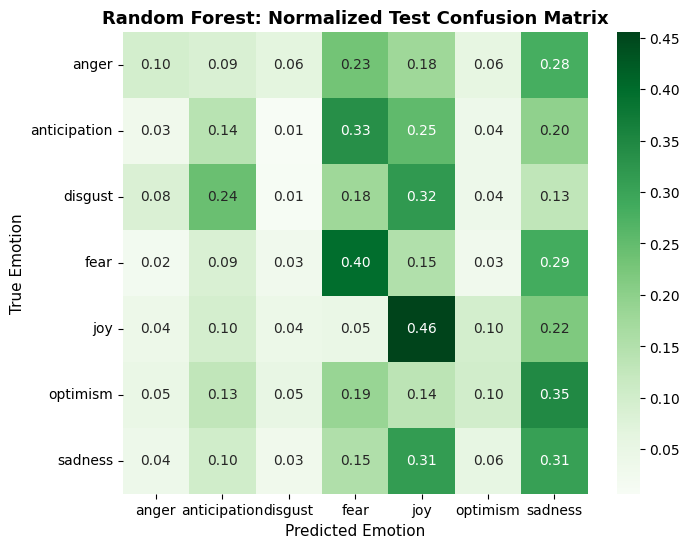

✔ Normalized confusion matrix saved to: results/phase2/random_forest_confusion_matrix.png


In [15]:
# Test Confusion Matrix Heatmap
cm_norm_rf = confusion_matrix_normalized(test_metrics_rf["confusion_matrix"])

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(
    cm_norm_rf,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=LABELS,
    yticklabels=LABELS,
    cbar=True,
    ax=ax,
)
ax.set_title("Random Forest: Normalized Test Confusion Matrix", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Emotion", fontsize=11)
ax.set_ylabel("True Emotion", fontsize=11)

cm_plot_rf_path = PHASE2_DIR / "random_forest_confusion_matrix.png"
fig.savefig(cm_plot_rf_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Normalized confusion matrix saved to: {rel(cm_plot_rf_path)}")

In [16]:
# Overfitting and Generalization Gap Analysis
best_idx_rf = rf_search.best_index_
train_cv_macro_rf = float(rf_results.loc[best_idx_rf, "mean_train_macro_f1"])
val_cv_macro_rf = float(rf_results.loc[best_idx_rf, "mean_test_macro_f1"])
test_macro_rf = float(test_metrics_rf["macro_f1"])

cv_gap_rf = train_cv_macro_rf - val_cv_macro_rf
test_gap_rf = val_cv_macro_rf - test_macro_rf

gap_df_rf = pd.DataFrame([
    {"Evaluation Stage": "1. Training CV (Mean)", "Macro-F1": f"{train_cv_macro_rf:.4f}", "Gap from Previous": "-"},
    {"Evaluation Stage": "2. Validation CV (Mean)", "Macro-F1": f"{val_cv_macro_rf:.4f}", "Gap from Previous": f"{cv_gap_rf:+.4f} (CV Gap)"},
    {"Evaluation Stage": "3. Held-Out Test Set", "Macro-F1": f"{test_macro_rf:.4f}", "Gap from Previous": f"{test_gap_rf:+.4f} (Generalization Gap)"},
])

print("=== Generalization & Overfitting Gap Analysis ===")
print(gap_df_rf.to_string(index=False))
print(f"\nAnalysis: The train-to-val gap is {cv_gap_rf:.4f} and val-to-test gap is {test_gap_rf:.4f}.")

=== Generalization & Overfitting Gap Analysis ===
       Evaluation Stage Macro-F1            Gap from Previous
  1. Training CV (Mean)   0.7859                            -
2. Validation CV (Mean)   0.1708             +0.6151 (CV Gap)
   3. Held-Out Test Set   0.1942 -0.0234 (Generalization Gap)

Analysis: The train-to-val gap is 0.6151 and val-to-test gap is -0.0234.


### 12. Model Interpretation & Feature Importance
Inspect feature importance across the 200 trees in the optimal Random Forest ensemble:
1. Extract and align all 2,522 engineered feature names from the fitted preprocessor pipeline.
2. Tabulate and visualize the top 20 features averaged across the forest.

In [17]:
# Feature names reconstruction and alignment check
fitted_prep_rf = rf_search.best_estimator_.named_steps["prep"]
text_names = [f"text_{f}" for f in fitted_prep_rf.named_transformers_["text_features"].named_steps["tfidf"].get_feature_names_out()]
genre_names = [f"genre_{g}" for g in fitted_prep_rf.named_transformers_["genre_features"].named_steps["binarizer"].genres_]
wc_names = ["word_count"]
rating_names = ["Ratings"]

feature_names = np.array(text_names + genre_names + wc_names + rating_names)

print(f"Total Reconstructed Feature Names: {len(feature_names)}")
assert len(feature_names) == 2522, f"Expected 2,522 features, got {len(feature_names)}"

# Strict column slice alignment check against fitted ColumnTransformer
sample = X_train.iloc[:5]
sample_trans = fitted_prep_rf.transform(sample)
sample_dense = sample_trans.toarray() if hasattr(sample_trans, "toarray") else sample_trans

s_text = len(text_names)
s_genre = len(genre_names)
s_wc = len(wc_names)
s_rating = len(rating_names)

text_trans = fitted_prep_rf.named_transformers_["text_features"].transform(sample["Reviews"])
genre_trans = fitted_prep_rf.named_transformers_["genre_features"].transform(sample["genres"])
wc_trans = fitted_prep_rf.named_transformers_["word_count_features"].transform(sample["Reviews"])
rating_trans = fitted_prep_rf.named_transformers_["rating_features"].transform(sample[["Ratings"]])

np.testing.assert_allclose(sample_dense[:, :s_text], text_trans.toarray() if hasattr(text_trans, "toarray") else text_trans, rtol=1e-5, atol=1e-5)
np.testing.assert_allclose(sample_dense[:, s_text:s_text+s_genre], genre_trans, rtol=1e-5, atol=1e-5)
np.testing.assert_allclose(sample_dense[:, s_text+s_genre:s_text+s_genre+s_wc], wc_trans, rtol=1e-5, atol=1e-5)
np.testing.assert_allclose(sample_dense[:, s_text+s_genre+s_wc:], rating_trans, rtol=1e-5, atol=1e-5)
print("✔ Feature names array strictly verified and aligned across all 4 ColumnTransformer branches.")

Total Reconstructed Feature Names: 2522


✔ Feature names array strictly verified and aligned across all 4 ColumnTransformer branches.


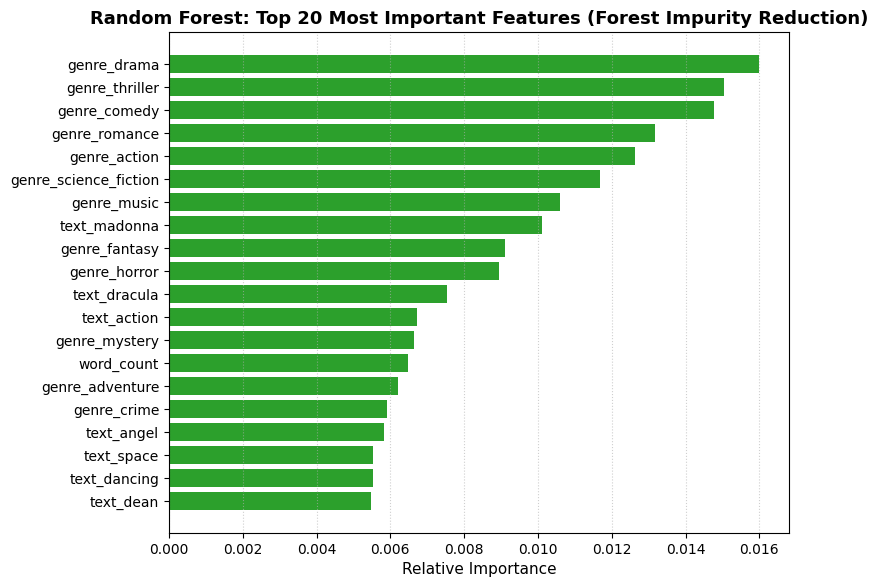

✔ Top 20 feature importance plot saved to: results/phase2/random_forest_feature_importance.png

Top 10 Features:
              feature  importance
          genre_drama    0.016004
       genre_thriller    0.015053
         genre_comedy    0.014768
        genre_romance    0.013165
         genre_action    0.012630
genre_science_fiction    0.011693
          genre_music    0.010608
         text_madonna    0.010121
        genre_fantasy    0.009104
         genre_horror    0.008954


In [18]:
# Feature importances extraction and horizontal bar chart
rf_clf = rf_search.best_estimator_.named_steps["clf"]
importances_rf = rf_clf.feature_importances_

importance_df_rf = pd.DataFrame({
    "feature": feature_names,
    "importance": importances_rf,
}).sort_values(by="importance", ascending=False)

top20_rf = importance_df_rf.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(top20_rf["feature"], top20_rf["importance"], color="#2ca02c")
ax.set_title("Random Forest: Top 20 Most Important Features (Forest Impurity Reduction)", fontsize=13, fontweight="bold")
ax.set_xlabel("Relative Importance", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6, axis="x")

fi_plot_rf_path = PHASE2_DIR / "random_forest_feature_importance.png"
fig.savefig(fi_plot_rf_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Top 20 feature importance plot saved to: {rel(fi_plot_rf_path)}")
print("\nTop 10 Features:")
print(importance_df_rf.head(10).to_string(index=False))

### 13. Artifact Persistence & Schema Validation
Serialize the full model results according to the Phase 2 standardized schema via `save_model_results()`. Validate the saved JSON artifact and test predictions CSV, export tuning diagnostics, and remove temporary pipeline caching directories.

In [19]:
meta_rf = {
    "model_label": "Random Forest",
    "member_id": "IT25102877",
    "algorithm": "RandomForestClassifier",
    "preprocessing": "TF-IDF (2500) + Genre Binarizer (20) + Word Count (1) + Rating (1)",
    "tuning": {
        "method": "RandomizedSearchCV",
        "n_configs": int(len(rf_results)),
        "n_folds": int(N_SPLITS),
        "scoring": list(SCORING.keys()),
        "elapsed_seconds": float(rf_elapsed),
        "best_params": {k: (v if v is not None else None) for k, v in rf_search.best_params_.items()},
    }
}

cv_payload_rf = cv_fold_scores(rf_search)

json_path_rf, csv_path_rf = save_model_results(
    out_dir=PHASE2_DIR,
    model_key="random_forest",
    meta=meta_rf,
    split=SPLIT_INFO,
    cv=cv_payload_rf,
    cv_fingerprints=CV_FINGERPRINTS,
    test=test_metrics_rf,
    baselines=BASELINES,
    predictions_df=predictions_df,
)

# Export tuning CV results and best parameters
rf_cv_csv = PHASE2_DIR / "random_forest_cv_results.csv"
rf_best_json = PHASE2_DIR / "random_forest_best_params.json"
rf_results.to_csv(rf_cv_csv, index=False)

def _sanitize_for_json(obj):
    if isinstance(obj, dict):
        return {k: _sanitize_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [_sanitize_for_json(v) for v in obj]
    elif hasattr(obj, "item"):
        return obj.item()
    return obj

best_params_summary_rf = {
    "best_params": {k: (v if v is not None else None) for k, v in rf_search.best_params_.items()},
    "best_cv_macro_f1_mean": float(rf_results.loc[rf_search.best_index_, "mean_test_macro_f1"]),
    "best_cv_macro_f1_std": float(rf_results.loc[rf_search.best_index_, "std_test_macro_f1"]),
    "best_cv_accuracy_mean": float(rf_results.loc[rf_search.best_index_, "mean_test_accuracy"]),
    "elapsed_seconds": float(rf_elapsed),
}
with open(rf_best_json, "w", encoding="utf-8") as f:
    json.dump(_sanitize_for_json(best_params_summary_rf), f, indent=2)

# Verify saved results
loaded_rf = load_model_results(json_path_rf)
validate_results(loaded_rf)

print("=== Phase 2 Standardized Model Artifacts Persisted ===")
print(f"• Evaluation JSON : {rel(json_path_rf)}")
print(f"• Predictions CSV : {rel(csv_path_rf)}")
print(f"• CV Results CSV  : {rel(rf_cv_csv)}")
print(f"• Best Params JSON: {rel(rf_best_json)}")
print("\n✔ Artifact schema validated: all cryptographic hashes, confusion matrix consistency, and row counts verified.")

=== Phase 2 Standardized Model Artifacts Persisted ===
• Evaluation JSON : results/phase2/random_forest_results.json
• Predictions CSV : results/phase2/random_forest_test_predictions.csv
• CV Results CSV  : results/phase2/random_forest_cv_results.csv
• Best Params JSON: results/phase2/random_forest_best_params.json

✔ Artifact schema validated: all cryptographic hashes, confusion matrix consistency, and row counts verified.


In [20]:
# Clean up temporary disk cache
shutil.rmtree(CACHE_DIR, ignore_errors=True)
print(f"✔ Pipeline cache directory removed: {rel(CACHE_DIR)}")

✔ Pipeline cache directory removed: sk_cache_rf_bm6e1lc3


### 14. Summary & Conclusions
Synthesize experimental outcomes through programmatically verified summary metrics and qualitative findings.

In [21]:
# Programmatically computed summary metrics
top20_feats_rf = importance_df_rf.head(20)["feature"].tolist()
genre_count_rf = sum(1 for f in top20_feats_rf if f.startswith("genre_"))
text_count_rf = sum(1 for f in top20_feats_rf if f.startswith("text_"))
numeric_count_rf = sum(1 for f in top20_feats_rf if f in ["word_count", "Ratings"])

per_class_f1_rf = [(cls, test_metrics_rf["per_class"][cls]["f1"]) for cls in LABELS]
per_class_f1_sorted_rf = sorted(per_class_f1_rf, key=lambda x: x[1])
worst_two_rf = per_class_f1_sorted_rf[:2]
best_two_rf = per_class_f1_sorted_rf[-2:][::-1]

print("=== Random Forest Model Evaluation Summary ===")
print(f"Optimal Hyperparameters   : {rf_search.best_params_}")
print(f"Cross-Validation Macro-F1  : {cv_scores_rf['macro_f1']['mean']:.4f} ± {cv_scores_rf['macro_f1']['std']:.4f}")
print(f"Test Accuracy              : {test_metrics_rf['accuracy']:.4f}")
print(f"Test Macro-F1              : {test_metrics_rf['macro_f1']:.4f}")
print(f"Test Weighted-F1           : {test_metrics_rf['weighted_f1']:.4f}")
print(f"Best Two Classes (by F1)   : {best_two_rf[0][0]} ({best_two_rf[0][1]:.4f}), {best_two_rf[1][0]} ({best_two_rf[1][1]:.4f})")
print(f"Worst Two Classes (by F1)  : {worst_two_rf[0][0]} ({worst_two_rf[0][1]:.4f}), {worst_two_rf[1][0]} ({worst_two_rf[1][1]:.4f})")
print(f"Stratified Random Baseline : Macro-F1 = {BASELINES['stratified_random']['macro_f1_mean']:.4f} ± {BASELINES['stratified_random']['macro_f1_std']:.4f}")
print(f"Top 20 Features Breakdown  : {genre_count_rf} genre, {text_count_rf} text, {numeric_count_rf} numeric")

# Optional comparison with Decision Tree CV std if available
dt_results_file = PHASE2_DIR / "decision_tree_results.json"
if dt_results_file.exists():
    try:
        dt_res = load_model_results(dt_results_file)
        dt_std = dt_res["cv"]["macro_f1"]["std"]
        rf_std = cv_scores_rf["macro_f1"]["std"]
        if rf_std < dt_std:
            print(f"Cross-Model Comparison     : Random Forest shows lower fold-to-fold spread, which is only suggestive with 5 folds (RF std {rf_std:.4f} vs DT std {dt_std:.4f}).")
    except Exception:
        pass

=== Random Forest Model Evaluation Summary ===
Optimal Hyperparameters   : {'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 16, 'clf__class_weight': 'balanced_subsample'}
Cross-Validation Macro-F1  : 0.1708 ± 0.0138
Test Accuracy              : 0.2729
Test Macro-F1              : 0.1942
Test Weighted-F1           : 0.2707
Best Two Classes (by F1)   : sadness (0.3669), joy (0.3403)
Worst Two Classes (by F1)  : disgust (0.0093), anger (0.1125)
Stratified Random Baseline : Macro-F1 = 0.1427 ± 0.0062
Top 20 Features Breakdown  : 12 genre, 7 text, 1 numeric
Cross-Model Comparison     : Random Forest shows lower fold-to-fold spread, which is only suggestive with 5 folds (RF std 0.0138 vs DT std 0.0211).


### 14. Qualitative Summary & Modeling Discussion

- **Evaluation Metric:** Macro-F1 serves as the primary optimization and comparison metric because raw classification accuracy heavily rewards predicting the majority class (`sadness`), masking poor performance on minority emotional categories.
- **Model Selection & Optimism:** Because the best hyperparameter configuration was chosen from 15 candidate configurations, its cross-validation score incorporates a small degree of selection optimism. The held-out test evaluation provides the unbiased estimate of generalization.
- **Feature Representation & Movie Context:** Genre columns are movie-level features and the label belongs to each movie, so genre importance predominantly reflects movie type rather than review-specific linguistic expressions.
- **Lexical Splitting & Memorization:** In high-dimensional sparse TF-IDF spaces, individual trees in the forest can split on specific words or names that identify individual movies in the training sample.